# Конспект. Модуль 1: Введение в рекомендательные системы

**Курс:** Мини-курс RecSys (13 модулей)
**Модуль:** 1 из 13 — «Введение: что такое рекомендации и зачем они нужны»
**Цель модуля:** сформировать полное понимание предметной области с нуля — без этого фундамента все дальнейшие модули (алгоритмы, метрики, production-архитектура) будут восприниматься как набор несвязанных техник, а не как решение одной конкретной бизнес-задачи.

## 1.1 Суть рекомендательной системы

### 1.1.1 Определение с нуля

**Рекомендательная система (Recommender System, RecSys)** — это программная система, которая на основе имеющихся данных о пользователе и объектах (товарах, фильмах, треках, банковских продуктах) предсказывает, какие из этих объектов будут ему интересны, и предлагает их **без явного запроса** со стороны пользователя.

Разберём это определение по частям, потому что каждое слово здесь важно:

- **«На основе имеющихся данных»** — система не гадает случайно, а опирается на конкретные сигналы: что пользователь уже смотрел/покупал/оценивал, кто ещё что покупал, какие у товара характеристики. Без данных рекомендация невозможна — это принципиальное отличие от простого показа контента наугад.
- **«Предсказывает»** — ключевое слово. RecSys — это, по сути, задача машинного обучения: у нас есть история взаимодействий (обучающие данные) и мы хотим предсказать будущее взаимодействие (пользователь оценит товар высоко / кликнет / купит).
- **«Без явного запроса»** — это то, что отличает рекомендацию от поиска (подробнее — в 1.1.2). Пользователь не формулирует, что он хочет — система должна понять это сама.

### 1.1.2 Разница «поиск vs рекомендация» — фундаментальное различие

Это первое, что нужно чётко зафиксировать, потому что путаница между этими двумя задачами — частая ошибка новичков.

| Критерий | Поиск (Search) | Рекомендация (Recommendation) |
|:---|:---|:---|
| Есть ли явный запрос | Да — пользователь вводит текст/фильтры («фильм Нолана», «кроссовки 42 размер, чёрные») | Нет — пользователь просто открывает главную страницу |
| Что известно системе | Точная формулировка намерения | Только косвенные сигналы: история, поведение, похожие пользователи |
| Какая задача решается | Найти объекты, максимально релевантные заданному запросу | Предсказать, что понравится, даже когда пользователь сам не знает, что хочет |
| Типичная метрика | Релевантность запросу (например, BM25, TF-IDF совпадение) | Персонализированная релевантность (зависит от истории конкретного пользователя) |
| Пример вопроса, на который отвечает система | «Что из каталога соответствует запросу X?» | «Что этому конкретному пользователю будет интересно прямо сейчас?» |

**Важный нюанс:** на практике эти две задачи часто пересекаются и используют схожий технический аппарат (эмбеддинги, ranking-модели — вы увидите это в модулях 10-11). Но с точки зрения **постановки задачи** они принципиально разные: в поиске у вас есть якорь (запрос), от которого можно оттолкнуться и посчитать релевантность; в рекомендации такого якоря нет, и приходится опираться исключительно на профиль пользователя.

Именно поэтому RecSys — сложнее в некотором смысле: система должна «угадать» намерение, которое никто явно не сформулировал.

### 1.1.3 Где встречаются рекомендательные системы — детальный разбор примеров

| Компания/сфера | Что именно рекомендуется | Какой тип сигнала используется |
|:---|:---|:---|
| **Netflix** | Фильмы и сериалы на главной странице, в каждом «ряду» (Row) | Implicit (что досмотрел, что бросил) + Explicit (оценки, thumbs up/down) |
| **Spotify** | Плейлисты Discover Weekly, Daily Mix, рекомендации похожих треков | Implicit (прослушивания, пропуски, добавления в избранное) |
| **YouTube** | Главная лента, блок «Далее», автовоспроизведение | Implicit (клики, время просмотра, лайки/дизлайки) |
| **Amazon** | «С этим товаром покупают», «Похожие товары», персональная лента | Implicit (просмотры, покупки) + explicit (отзывы) |
| **Wildberries / Ozon** | Главная страница, карточка товара («похожие»), корзина («с этим товаром покупают») | Implicit (клики, добавления в корзину, покупки) |
| **Т-Банк** | Рекомендации кредитных карт, вкладов, инвестиционных продуктов, персональные предложения в приложении | Implicit (использование других продуктов, транзакционная активность) + анкетные/демографические данные |
| **Avito** | Похожие объявления, «Возможно вас заинтересует» | Implicit (просмотры объявлений, избранное, отклики) |

**Почему важно отдельно выделить Т-Банк:** в отличие от Netflix/Spotify, где объект рекомендации — «развлекательный контент» с низкой ценой ошибки (плохая рекомендация фильма — просто не кликнули), в банковской сфере рекомендация финансового продукта — это высокая ответственность: неверная рекомендация может означать неподходящий кредитный продукт для конкретной финансовой ситуации пользователя. Это важный нюанс, который стоит держать в голове при подготовке к интервью в Т-Банк — там могут спросить не только «как это работает технически», но и «как вы обеспечите, что рекомендация не навредит пользователю» (тема ответственного ML, обычно поднимается в контексте fairness/этики моделей).

### 1.1.4 Зачем это компаниям — конкретные цифры и логика

Рекомендательные системы — это не просто «приятная фича», это прямой источник выручки и удержания пользователей. Логика простая:

1. **Экономика внимания.** У пользователя ограниченное время и терпение. Если он не находит интересное за первые секунды — он уходит (к конкуренту или просто закрывает приложение).
2. **Каталог намного больше, чем то, что человек способен просмотреть вручную.** У Netflix — десятки тысяч единиц контента, у Wildberries — десятки миллионов товаров. Без персонализации пользователь физически не может найти то, что ему подходит, среди такого объёма.
3. **Прямая монетизация:**
   - Netflix публично заявлял, что персонализация рекомендаций экономит компании порядка **$1 млрд в год** за счёт удержания подписчиков (снижения оттока/churn).
   - У маркетплейсов (Amazon, Wildberries) значительная доля заказов приходит именно через рекомендательные блоки на главной странице и в карточке товара — это не побочный эффект, а спроектированный канал продаж.
   - У Т-Банка рекомендации продуктов напрямую влияют на **cross-sell** (продажа дополнительных продуктов существующим клиентам) — это один из самых дешёвых способов роста выручки, поскольку не требует привлечения нового клиента.

### 1.1.5 Исторический контекст: почему область вообще стала настолько развитой

Полезно понимать не только «что такое RecSys», но и откуда область выросла как отдельная дисциплина машинного обучения.

**Netflix Prize (2006–2009)** — знаковое событие в истории RecSys. Netflix объявил открытый конкурс с призом $1 млн за улучшение точности их алгоритма предсказания рейтингов (Cinematch) на 10% по метрике RMSE. Именно этот конкурс:
- Популяризировал методы матричной факторизации (SVD, о которых пойдёт речь в Модуле 5) как мощный инструмент для RecSys.
- Показал, что ансамбли моделей (комбинация десятков разных алгоритмов) дают заметный прирост качества — задолго до того, как ансамблирование стало мейнстримом в остальном ML.
- Сформировал целое сообщество исследователей, из работ которых выросла значительная часть современного инструментария (включая идеи, которые вы встретите в модулях про ALS и BPR).

Знание этого контекста полезно не столько само по себе, сколько потому, что оно объясняет, **почему** именно матричная факторизация исторически стала таким центральным методом в RecSys — это не случайный выбор, а результат конкретного крупного эксперимента с огромным количеством участников и подходов.

## 1.2 Типы рекомендательных систем

Здесь мы даём обзорную карту — детальная механика каждого подхода разбирается в последующих модулях (3, 4, 5, 6, 7). Задача этого раздела — понять **принципиальные различия** между подходами и когда какой применим.

### 1.2.1 Коллаборативная фильтрация (Collaborative Filtering, CF)

**Принцип:** «люди, похожие на вас в прошлом, укажут, что вам понравится в будущем» — либо через похожих **людей** (User-Based CF, Модуль 3), либо через похожие **товары** на основе того, что их покупают одни и те же люди (Item-Based CF, Модуль 4), либо через компактное скрытое представление вкусов (Matrix Factorization, Модуль 5).

**Ключевая особенность:** CF **не использует никакой информации о содержании** товара — ему всё равно, что за фильм, какой у него жанр или актёры. Единственный вход — кто с кем и как взаимодействовал.

**Пример:** «Пользователи, похожие на вас, купили…» — классическая формулировка Amazon.

**Плюс:** может находить неочевидные, «серендипные» связи (пункт 1.5.5), которые невозможно вывести из простого анализа контента.
**Минус:** не работает без истории взаимодействий — отсюда прямая связь с проблемой холодного старта (1.5.1).

### 1.2.2 Контентная фильтрация (Content-Based Filtering)

**Принцип:** «товары похожи на товары» по своим внутренним характеристикам — жанр, описание, цена, бренд. Строится профиль товара (вектор признаков) и профиль пользователя (агрегат признаков понравившихся товаров), и рекомендуются товары, максимально похожие на профиль пользователя.

**Пример:** «Похоже на то, что вы смотрели» — рекомендация, полностью объяснимая содержанием (два фильма одного жанра/режиссёра).

**Плюс:** работает даже для абсолютно нового товара — не нужно, чтобы его кто-то оценил, достаточно описания.
**Минус:** редко выходит за рамки уже знакомого — низкая способность удивить (проблема низкой serendipity, разбирается в 1.5.5 и подробно в Модуле 6).

### 1.2.3 Гибридные системы (Hybrid)

**Принцип:** комбинация коллаборативного и контентного подходов (и иногда других), чтобы компенсировать слабые стороны каждого по отдельности.

**Пример:** современные production-системы почти никогда не бывают «чисто» коллаборативными или «чисто» контентными — это всегда та или иная комбинация (подробная классификация типов гибридизации — в Модуле 7).

### 1.2.4 На основе знаний (Knowledge-Based)

**Принцип:** рекомендация строится не через статистику взаимодействий, а через явно заданные экспертные правила и ограничения — часто используется там, где решение сложное, редкое и дорогое (недвижимость, автомобили, финансовые продукты с юридическими ограничениями).

**Пример:** «Если возраст пользователя > 60 -> рекомендовать ОСАГО с определёнными условиями» — жёсткое бизнес-правило, а не статистический вывод.

**Плюс:** предсказуем и объясним — критично, когда ошибка дорога (в отличие от «просто не тот фильм»).
**Минус:** не адаптируется автоматически к новым паттернам поведения — требует ручного обновления правил.

### 1.2.5 Сводная таблица для быстрого сравнения

| Тип | Нужна ли история взаимодействий | Нужны ли признаки товара | Способен на неожиданные находки | Где чаще используется |
|:---|:---|:---|:---|:---|
| Коллаборативная | Да (критично) | Нет | Да, высокая | Netflix, Amazon (основной движок) |
| Контентная | Нет | Да (критично) | Нет, низкая | Новости, новые товары, cold start fallback |
| Гибридная | Частично | Частично | Средняя-высокая | Большинство крупных production-систем |
| На основе знаний | Нет | Нет (используются правила) | Нет | Финансы, недвижимость, дорогие/редкие покупки |

## 1.3 Постановка задачи: explicit vs implicit feedback

### 1.3.1 Explicit feedback (явная обратная связь)

Пользователь **сознательно и целенаправленно** сообщает системе своё отношение к объекту.

**Формы explicit feedback:**
- Оценка по шкале (звёзды 1–5, как в классическом MovieLens и старом Netflix).
- Бинарная оценка (лайк/дизлайк, как в YouTube, Spotify).
- Явный текстовый отзыв (сложнее использовать напрямую в классических моделях, обычно обрабатывается отдельно через NLP).

**Плюсы explicit feedback:**
- Сигнал «чистый» — если пользователь поставил 5 звёзд, это осознанное действие, отражающее его реальное отношение.
- Легко интерпретировать как для rating prediction (1.3.3), так и для построения бинарной метки «понравилось / не понравилось».

**Минусы explicit feedback:**
- **Люди редко ставят оценки.** Статистически, доля пользователей, которые вообще что-то явно оценивают, обычно составляет единицы процентов от всех, кто взаимодействует с платформой. Это значит, что explicit-данных **систематически мало**, и модель, обученная только на них, будет знать о поведении лишь небольшой, нерепрезентативной части аудитории (те, кто вообще склонен ставить оценки, — уже не случайная выборка пользователей).
- **Selection bias:** пользователи чаще оценивают либо то, что им очень понравилось, либо то, что сильно не понравилось — середина шкалы систематически недопредставлена.

### 1.3.2 Implicit feedback (неявная обратная связь)

Отношение пользователя выводится **не из явного действия оценки, а из поведения**.

**Формы implicit feedback:**
- Просмотр (открыл карточку товара / начал смотреть видео).
- Клик.
- Время, проведённое на странице / доля просмотренного видео.
- Покупка / добавление в корзину.
- Повторное обращение к объекту.

**Плюсы implicit feedback:**
- **Данных на порядки больше** — фиксируется вообще всё поведение, а не только осознанные оценки.
- Не требует от пользователя никаких дополнительных усилий — собирается автоматически, «бесплатно» для пользователя.

**Минусы implicit feedback (важно понимать все нюансы — это будет использовано в математике Модуля 5):**
- **Нет явного негатива.** Если пользователь не кликнул на товар — это может значить «не понравилось», а может значить «просто не заметил» (товар был внизу страницы), «не было времени посмотреть», «уже купил в другом месте». Система в принципе не может отличить эти случаи напрямую — только по косвенным признакам.
- **Шум:** клик не всегда означает интерес — может быть случайным (промахнулся пальцем на мобильном устройстве), кликбейтным (привлекательное превью, но неинтересное содержание), или сделанным из любопытства без реального намерения.
- **Асимметрия сигнала:** «купил» — сильный положительный сигнал; «посмотрел 2 секунды и закрыл» — скорее слабый негативный сигнал, но технически это тоже «взаимодействие», и наивная модель может интерпретировать оба события одинаково, если не проектировать признаки аккуратно.

**Почему это критично для дальнейших модулей:** именно из-за отсутствия явного негатива в implicit-данных появляются специальные методы — confidence-взвешивание в ALS (Модуль 5.5) и pairwise-обучение в BPR (Модуль 5.6, 9.3), которые не пытаются предсказать «оценку», а вместо этого работают с относительным порядком предпочтений.

### 1.3.3 Rating prediction vs Ranking — две разные постановки задачи

Это второе фундаментальное разделение (после explicit/implicit), которое нужно чётко удерживать в голове на протяжении всего курса.

**Rating Prediction**
- Задача: предсказать точное числовое значение оценки, которое пользователь поставил бы объекту (например, 4.3 из 5).
- Типичная метрика: RMSE, MAE (подробнее в Модуле 8.1).
- Исторически это была основная постановка задачи (именно её решал Netflix Prize) — но у неё есть существенный практический недостаток.

**Ranking (Top-K)**
- Задача: выдать упорядоченный список из K лучших объектов для пользователя — не важны точные числовые оценки, важен только правильный **порядок**.
- Типичные метрики: Precision@K, Recall@K, NDCG (детально разбираются в Модуле 8).
- Это главная задача в реальном production: пользователю показывают 10 позиций на главной странице — неважно, что модель думает, будто он поставил бы фильму рейтинг 4.3, а не 4.1, важно только то, что этот фильм должен стоять **выше** в списке, чем менее релевантные варианты.

**Почему разница принципиальна, а не просто техническая деталь:**
Представим, модель А точно предсказывает рейтинги (низкий RMSE), но систематически неверно упорядочивает топ-10 товаров. Модель Б предсказывает рейтинги менее точно в абсолютных числах, но безошибочно ставит самые релевантные товары на первые места. С точки зрения бизнеса (где пользователь видит только верхние 10 позиций) модель Б значительно ценнее, хотя её RMSE хуже. Это ключевая причина, по которой современные production-системы (и весь блок Learning to Rank, Модуль 9) сфокусированы именно на ranking, а не на rating prediction — это прямое отражение того, как рекомендации реально потребляются пользователем.

## 1.4 Матрица взаимодействий User-Item

### 1.4.1 Представление

Базовая структура данных для почти всех алгоритмов RecSys — матрица, где:
- **строки** соответствуют пользователям,
- **столбцы** — товарам (items),
- **ячейка** `R[u][i]` содержит рейтинг или факт взаимодействия пользователя `u` с товаром `i`.

**Наглядный пример** (5 пользователей, 5 фильмов, шкала 1–5, пусто = нет взаимодействия):

| | Фильм 1 | Фильм 2 | Фильм 3 | Фильм 4 | Фильм 5 |
|:---|:---:|:---:|:---:|:---:|:---:|
| Пользователь A | 5 | — | — | 3 | — |
| Пользователь B | — | 4 | — | — | — |
| Пользователь C | — | — | 2 | — | 5 |
| Пользователь D | 4 | — | — | — | — |
| Пользователь E | — | — | — | 5 | — |

Уже на этом крошечном примере (25 ячеек) видно: заполнено только 6 из 25 ячеек — **76% матрицы пусто**. И это ещё очень плотный пример для иллюстрации — в реальных системах ситуация значительно хуже (следующий пункт).

### 1.4.2 Разреженность (Sparsity) — центральная проблема всей области

**Формула:**

In [ ]:
Sparsity = 1 - (число ненулевых ячеек) / (число пользователей × число товаров)

**Расчёт для реалистичного примера:**
- 100 000 пользователей, 10 000 фильмов -> всего возможных ячеек: `100 000 × 10 000 = 1 000 000 000` (1 миллиард).
- Пусть каждый пользователь в среднем посмотрел 100 фильмов -> заполненных ячеек: `100 000 × 100 = 10 000 000` (10 миллионов).
- `Sparsity = 1 - (10 000 000 / 1 000 000 000) = 1 - 0.01 = 0.99` -> **99% матрицы пусто.**

Для сравнения — реальные крупные платформы (Amazon, Netflix) часто демонстрируют разреженность **99.9% и выше**. Это не аномалия, а фундаментальное свойство задачи: ни один пользователь физически не способен взаимодействовать с сколько-нибудь значимой долей многомиллионного каталога.

### 1.4.3 Почему разреженность — это не просто «статистический факт», а причина, определяющая выбор алгоритмов

Разреженность напрямую объясняет, почему в курсе будет именно такая последовательность методов:

1. **Прямое сравнение пользователей/товаров (Модули 3–4)** технически возможно, но становится крайне ненадёжным при такой разреженности: у двух случайных пользователей может просто не быть ни одного общего оценённого товара, и сравнивать их не с чем.
2. **Хранение полной матрицы в памяти становится нецелесообразным** — 1 миллиард ячеек по 4–8 байт каждая (даже для скромного примера выше) уже требует гигабайты памяти, притом 99% из них — впустую хранимые нули. Отсюда прямая связь со специальными форматами хранения разреженных матриц (CSR, COO — разбираются в Модуле 2.1) и библиотекой `scipy.sparse`.
3. **Матричная факторизация (Модуль 5)** — прямой ответ на проблему разреженности: вместо работы с гигантской разреженной матрицей напрямую, мы сжимаем информацию о каждом пользователе и товаре в компактный плотный вектор (50–200 чисел), который **обучается только на тех ячейках, которые реально заполнены**, и позволяет предсказывать значения для пустых ячеек через простое скалярное произведение.

### 1.4.4 Разреженность и длинный хвост (long tail)

Отдельный, но тесно связанный эффект: заполненность матрицы не только мала в целом, но и **крайне неравномерна** — небольшая доля популярных товаров получает подавляющее большинство взаимодействий, а огромный «длинный хвост» товаров — почти ничего. Это явление напрямую связано с проблемой Popularity Bias (1.5.3) и будет играть важную роль при обсуждении метрик Coverage/Diversity (Модуль 8.7) и стратегий их улучшения (Модуль 12.2).

## 1.5 Ключевые проблемы рекомендательных систем

Это раздел, который стоит знать почти наизусть для собеседования — вопрос «какие проблемы есть в RecSys и как их решать» практически гарантированно встретится на техническом интервью.

### 1.5.1 Cold Start (проблема холодного старта)

Разделяется на три различных подтипа, которые часто путают между собой:

**Cold Start пользователя (New User Problem)**
- Ситуация: новый пользователь только что зарегистрировался, истории взаимодействий нет вообще.
- Почему это проблема: коллаборативная фильтрация (1.2.1) в принципе не может работать — нет данных, чтобы найти похожих пользователей или посчитать скрытые факторы для этого человека.
- Направление решения (детали — в Модуле 7 и 12.1): popularity-based рекомендации как временный fallback, onboarding-опросы («выберите интересные категории»), использование демографических данных, если они доступны.

**Cold Start товара (New Item Problem)**
- Ситуация: товар только что добавлен в каталог, ни один пользователь ещё с ним не взаимодействовал.
- Почему это проблема: у коллаборативной фильтрации просто нет строки/столбца с данными для этого товара — его физически не с чем сравнивать в терминах взаимодействий.
- Направление решения: контентная фильтрация (1.2.2), которая работает по метаданным товара, а не по истории взаимодействий, плюс искусственное «продвижение» новых товаров в выдаче для быстрого сбора первых сигналов.

**Cold Start системы (New System / New Platform Problem)**
- Ситуация: платформа только что запущена, данных нет вообще ни по пользователям, ни по товарам.
- Направление решения: экспертные правила (Knowledge-Based подход, 1.2.4), ручные подборки редакторов, простая популярность (если есть хоть какие-то внешние данные).

### 1.5.2 Scalability (масштабируемость)

- Суть проблемы: наивные алгоритмы (например, прямое попарное сравнение всех пользователей друг с другом, User-Based CF из Модуля 3) имеют сложность `O(N²)` или хуже относительно числа пользователей `N`.
- **Конкретная иллюстрация:** при 100 миллионах пользователей и 10 миллионах товаров, попытка сравнить каждого пользователя с каждым другим — это `~10^16` операций, что абсолютно нереализуемо даже на самых мощных кластерах в разумное время.
- Это прямая причина, по которой курс движется от memory-based методов (Модули 3–4, работающих «в лоб») к матричной факторизации (Модуль 5, сжимающей представление) и далее к архитектурам ANN/FAISS (Модуль 11), которые изначально спроектированы для работы на миллионах и миллиардах объектов.

### 1.5.3 Popularity Bias

- Суть проблемы: поскольку про популярные товары накоплено значительно больше данных (просто потому, что с ними взаимодействовало больше людей), модель статистически увереннее в своих предсказаниях именно для них — и начинает рекомендовать преимущественно один и тот же узкий набор «хитов» всем подряд, независимо от индивидуальных различий пользователей.
- **Самоусиливающийся эффект (feedback loop):** товар рекомендуют чаще -> его чаще видят -> он получает больше кликов просто за счёт видимости -> модель ещё больше убеждается в его популярности -> рекомендует ещё чаще. Этот цикл детально разбирается в Модуле 12.2, где также разбираются методы противодействия (re-ranking с учётом diversity, exploration-стратегии).
- Практическое следствие: метрика точности (Precision@K) может расти, даже если реальная польза для пользователя (открытие нового, персонализация) падает — это прямая иллюстрация того, почему одной метрики точности недостаточно (подробнее — Модуль 8.7).

### 1.5.4 Grey Sheep (проблема «серых овец»)

- Суть проблемы: некоторые пользователи имеют настолько нетипичные, идиосинкратические вкусы, что для них статистически не находится достаточно похожих людей — коллаборативная фильтрация в принципе плохо работает именно для этой категории пользователей, даже если у них накоплена большая история взаимодействий (в отличие от cold start, где проблема — отсутствие данных, здесь проблема — отсутствие «соседей», даже когда данных достаточно).
- Термин противопоставляется «white sheep» (пользователи с типичными, легко группируемыми предпочтениями) и «black sheep» (пользователи, для которых система принципиально не может дать хорошую рекомендацию никаким методом).
- Практическое следствие: для таких пользователей контентная фильтрация (1.2.2) или гибридные подходы (1.2.3, Модуль 7) часто работают лучше, чем чистая коллаборативная фильтрация, потому что не зависят от наличия «похожих» людей.

### 1.5.5 Serendipity, Novelty и Diversity — три разных, но часто путаемых понятия

Эти три термина регулярно путают между собой, поэтому стоит зафиксировать чёткие определения уже на старте (полная метрическая формализация — в Модуле 8.7):

| Термин | Определение | Пример |
|:---|:---|:---|
| **Novelty (новизна)** | Насколько рекомендованный объект непопулярен/малоизвестен в целом (не обязательно неожиданен именно для этого пользователя) | Рекомендация редкого инди-фильма, который мало кто смотрел |
| **Diversity (разнообразие)** | Насколько рекомендованные объекты **внутри одного списка** отличаются друг от друга | Топ-10 не состоит из 10 фильмов одного жанра |
| **Serendipity (приятная неожиданность)** | Объект одновременно релевантен **и** неожидан именно для конкретного пользователя (пересечение новизны и релевантности) | Пользователь, смотревший только боевики, получает неожиданную, но точно попавшую в его текущее настроение драму |

**Почему это важно понимать уже здесь:** система, максимизирующая только точность (Precision@K), склонна деградировать в сторону предсказуемых, безопасных рекомендаций (в пределе — просто топ-популярное, см. Popularity Bias выше) — с высокой точностью, но нулевой ценностью открытия нового. Именно баланс между точностью и этими тремя качественными характеристиками — одна из центральных инженерных дилемм всей области RecSys, к которой курс будет возвращаться в модулях 8, 11 и 12.

## 1.6 Практика: анализ MovieLens 1M

### 1.6.1 Цель практического блока

Прежде чем строить любые модели (Модули 3+), нужно научиться **видеть структуру данных своими глазами** — понимать реальный масштаб разреженности, распределение активности пользователей и распределение оценок. Это тот же принцип, что EDA перед построением ML-модели, с которым вы уже знакомы по предыдущим неделям общего плана.

### 1.6.2 Загрузка датасета

In [2]:
import pandas as pd
import numpy as np

# MovieLens 1M: ratings.dat содержит user_id::movie_id::rating::timestamp
ratings = pd.read_csv(
    'Data/ml-1m/ratings.dat',
    sep='::',
    engine='python',
    names=['user_id', 'movie_id', 'rating', 'timestamp'],
    encoding='latin-1'
)

print(ratings.shape)          # ожидаем ~1 000 209 строк
print(ratings.head())
print(f"Уникальных пользователей: {ratings['user_id'].nunique()}")
print(f"Уникальных фильмов: {ratings['movie_id'].nunique()}")

(1000209, 4)
   user_id  movie_id  rating  timestamp
0        1      1193       5  978300760
1        1       661       3  978302109
2        1       914       3  978301968
3        1      3408       4  978300275
4        1      2355       5  978824291
Уникальных пользователей: 6040
Уникальных фильмов: 3706


### 1.6.3 Расчёт разреженности матрицы (прямое применение формулы из 1.4.2)

In [3]:
n_users = ratings['user_id'].nunique()
n_items = ratings['movie_id'].nunique()
n_ratings = len(ratings)

total_possible_cells = n_users * n_items
sparsity = 1 - (n_ratings / total_possible_cells)

print(f"Пользователей: {n_users}")
print(f"Фильмов: {n_items}")
print(f"Заполненных ячеек: {n_ratings}")
print(f"Всего возможных ячеек: {total_possible_cells}")
print(f"Sparsity: {sparsity:.4%}")
# Ожидаемый результат для MovieLens 1M: sparsity ~95.5%

Пользователей: 6040
Фильмов: 3706
Заполненных ячеек: 1000209
Всего возможных ячеек: 22384240
Sparsity: 95.5316%


**Интерпретация результата:** даже на относительно небольшом и специально подготовленном для исследований датасете (MovieLens создан именно для того, чтобы быть «плотнее» реальных промышленных данных за счёт отбора только активных пользователей) разреженность уже превышает 95%. Это подтверждает тезис из 1.4.2 — реальные системы будут ещё более разреженными.

### 1.6.4 Гистограмма распределения рейтингов

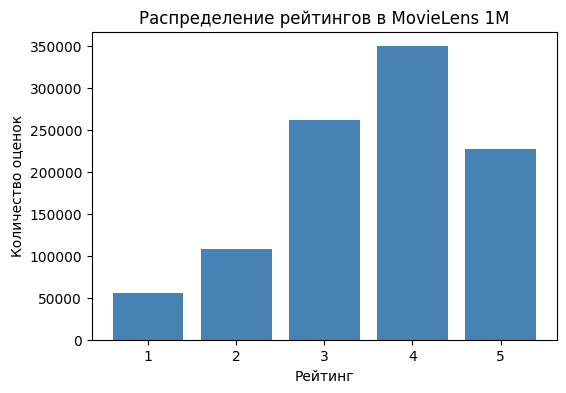

rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64


In [10]:
import matplotlib.pyplot as plt

rating_counts = ratings['rating'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(rating_counts.index, rating_counts.values, color='steelblue')
plt.xlabel('Рейтинг')
plt.ylabel('Количество оценок')
plt.title('Распределение рейтингов в MovieLens 1M')
plt.show()

print(rating_counts)

**На что обратить внимание в результате:** распределение почти всегда смещено в сторону высоких оценок (4-5) — это прямая иллюстрация selection bias из explicit feedback (1.3.1): люди чаще оценивают то, что им понравилось, чем то, к чему они равнодушны — оценка требует осознанного усилия, и на это усилие чаще идут при сильных эмоциях (позитивных или явно негативных), а не при нейтральном отношении.

### 1.6.5 Поиск «супер-активных» и «супер-неактивных» пользователей

Топ-5 самых активных пользователей:
user_id
4169    2314
1680    1850
4277    1743
1941    1595
1181    1521
dtype: int64

Топ-5 наименее активных пользователей:
user_id
708     20
703     20
665     20
2160    20
4749    20
dtype: int64

Медиана числа оценок на пользователя: 96.0
Среднее число оценок на пользователя: 165.6
Максимум: 2314, Минимум: 20


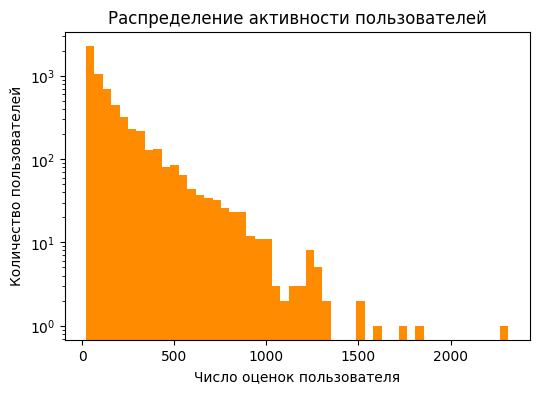

In [13]:
# Число оценок на пользователя
user_activity = ratings.groupby('user_id').size().sort_values(ascending=False)

print("Топ-5 самых активных пользователей:")
print(user_activity.head())

print("\nТоп-5 наименее активных пользователей:")
print(user_activity.tail())

print(f"\nМедиана числа оценок на пользователя: {user_activity.median()}")
print(f"Среднее число оценок на пользователя: {user_activity.mean():.1f}")
print(f"Максимум: {user_activity.max()}, Минимум: {user_activity.min()}")

# Дополнительно: посмотреть, насколько неравномерно распределена активность
plt.figure(figsize=(6, 4))
plt.hist(user_activity, bins=50, color='darkorange')
plt.xlabel('Число оценок пользователя')
plt.ylabel('Количество пользователей')
plt.title('Распределение активности пользователей')
plt.yscale('log')  # логарифмическая шкала - иначе длинный хвост не виден
plt.show()

**Ожидаемый вывод:** распределение активности пользователей почти всегда сильно скошено (похоже на степенной закон / long tail, п. 1.4.4) — небольшое число пользователей генерирует непропорционально большую долю всех оценок. Это тот же структурный паттерн, что и распределение популярности товаров, и он будет прямо влиять на то, как вы будете формировать train/test split в дальнейших модулях (например, важно не потерять «холодных» пользователей при случайном сэмплировании).

### 1.6.6 Итоговые вопросы для самопроверки по итогам практики

После выполнения практики стоит уметь ответить (без подглядывания) на следующие вопросы — это тот уровень понимания, который потребуется на техническом интервью:

1. Почему разреженность 95% на MovieLens — это ещё «хороший» случай по сравнению с реальными промышленными системами?
2. Почему нельзя просто взять среднее по всем оценкам как baseline-рекомендацию для нового пользователя, не учитывая смещение в сторону высоких оценок?
3. Если пользователь имеет всего 2 оценки в датасете — к какой из проблем 1.5 это относится (cold start или grey sheep), и как отличить один случай от другого?

## Глоссарий модуля 1 (для быстрого повторения)

| Термин | Короткое определение |
|:---|:---|
| RecSys | Система, предсказывающая интересные пользователю объекты без явного запроса |
| Explicit feedback | Осознанная оценка пользователя (звёзды, лайк) |
| Implicit feedback | Оценка, выведенная из поведения (клик, покупка, время просмотра) |
| Rating Prediction | Задача предсказать точное числовое значение оценки |
| Ranking (Top-K) | Задача выдать правильно упорядоченный список из K объектов |
| User-Item матрица | Таблица «пользователь × товар» с рейтингами/взаимодействиями |
| Sparsity | Доля пустых ячеек в user-item матрице |
| Long Tail | Малая доля популярных товаров получает большинство взаимодействий |
| Cold Start | Проблема отсутствия данных для нового пользователя/товара/системы |
| Popularity Bias | Систематический перекос рекомендаций в сторону уже популярного |
| Grey Sheep | Пользователи с нетипичными вкусами, для которых нет «соседей» |
| Novelty | Насколько объект малоизвестен в целом |
| Diversity | Насколько разнообразен список рекомендаций |
| Serendipity | Пересечение релевантности и неожиданности |

**Связь со следующим модулем:** Модуль 2 даёт математический инструментарий (меры сходства, работа с разреженными матрицами), который непосредственно понадобится для реализации первых алгоритмов — User-Based и Item-Based CF (Модули 3–4), уже использующих разреженную user-item матрицу, разобранную здесь в разделе 1.4.